In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from motion_planning.database import Database
from motion_planning.database.db_annotator import populate_db
from motion_planning.experiments.utils.mp_sampler import MPSampler
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import OptimizedBiDirectionalPDG, OptimizedPDG
from motion_planning.space import ApproximationSpace, PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Base Robot & Environment

In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Setup Approximation Environment

In [3]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

/Users/pravaltelagi/motion_planning/motion_planning/space/approx/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


# Generate Path Database

In [4]:
db = Database()
mp_sampler = MPSampler(env, BiasedPassage, {"num_walls": 3, "bias": 0.5})

db_save_path = "../saves/optimized_pdg_example_database.pickle"
populate_db(db, mp_sampler, num_envs=2, num_tasks_per_env=20)
db.save_to_path(db_save_path)

Connecting Edges Using knn strategy
Env 1, Task 1
Num Times Extended: 0
Env 1, Task 2
Adding Nodes, Current Size: 839
Connecting Edges Using knn strategy
Adding Nodes, Current Size: 1679
Connecting Edges Using knn strategy
Adding Nodes, Current Size: 2500
Connecting Edges Using knn strategy
Num Times Extended: 3
Env 1, Task 3
Num Times Extended: 0
Env 1, Task 4
Num Times Extended: 0
Env 1, Task 5
Num Times Extended: 0
Env 1, Task 6
Num Times Extended: 0
Env 1, Task 7
Num Times Extended: 0
Env 1, Task 8
Num Times Extended: 0
Env 1, Task 9
Num Times Extended: 0
Env 1, Task 10
Num Times Extended: 0
Env 1, Task 11
Num Times Extended: 0
Env 1, Task 12
Num Times Extended: 0
Env 1, Task 13
Num Times Extended: 0
Env 1, Task 14
Num Times Extended: 0
Env 1, Task 15
Num Times Extended: 0
Env 1, Task 16
Num Times Extended: 0
Env 1, Task 17
Num Times Extended: 0
Env 1, Task 18
Num Times Extended: 0
Env 1, Task 19
Num Times Extended: 0
Env 1, Task 20
Num Times Extended: 0
DB Size: 20
Connecting Edge

# Create Task to Solve

In [5]:
start, target = (
    env.space.make_state(np.array([5.0, 5.0])),
    env.space.make_state(np.array([35.0, 5.0])),
)

# Display Task and Environment

/Users/pravaltelagi/motion_planning/motion_planning/space/approx/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


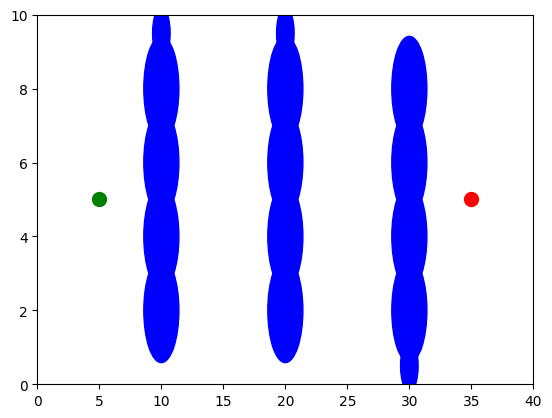

In [6]:
env.draw_environment(plt.gca())
plt.scatter(*start.value, color="green", s=100)
plt.scatter(*target.value, color="red", s=100)
plt.show()

# OptimizedPDG

In [7]:
optimized_pdg = OptimizedPDG(env, db_path=db_save_path)

# OptimizedPDG: Compute Guidance from Database Paths

In [8]:
optimized_pdg.compute_retained_paths(target)

# OptimizedPDG: Search

In [9]:
st = time.time()
path = optimized_pdg.search(start, target)
et = time.time()
print(f"Time to Search: {et - st}")

Found Path in 0 iterations
Time to Search: 0.004472970962524414


# OptimizedPDG: Draw Tree

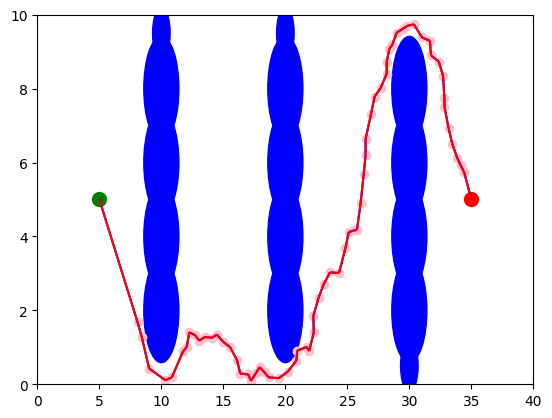

In [10]:
optimized_pdg.draw_tree(plt.gca(), path)
plt.show()

# BiDirectionalOptimizedPDG (BiDirOptimizedPDG)

In [11]:
bidirectional_optimized_pdg = OptimizedBiDirectionalPDG(env, db_save_path)

Time to Instantiate PDGs: 0.018862009048461914


# BiDirOptimizedPDG: Search

In [12]:
path = bidirectional_optimized_pdg.search(start, target)

Time to Compute Retained Paths: 0.004129886627197266
Time to Initialize Search: 0.0015208721160888672
Found Path in 0 iterations
Search Time: 0.09531497955322266, Collision Checks: 1842
Time to search (without computing retained paths): 0.1049959659576416
Time to backtrack path: 0.005548000335693359


/Users/pravaltelagi/motion_planning/motion_planning/utils/utils.py:97: RuntimeWarning: invalid value encountered in divide
  gradient /= edge_length


# BiDirOptimizedPDG: Draw Tree

/Users/pravaltelagi/motion_planning/motion_planning/space/approx/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


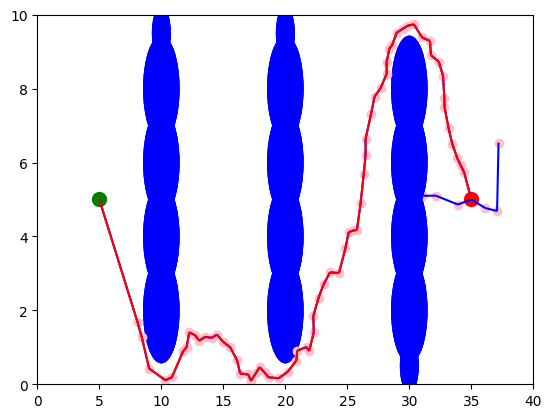

In [13]:
bidirectional_optimized_pdg.draw_tree(plt.gca(), path)
plt.show()